In [24]:
!pip install tifffile

import os
import numpy as np
import tifffile as tiff
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# The path confirmed by your previous code
data_dir = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands'

def load_eurosat_multispectral(base_path):
    images = []
    labels = []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(base_path, class_name)
        count = 0
        for img_name in os.listdir(class_path):
            if count >= 400: break # Load 400 images per class to manage memory
            
            img_path = os.path.join(class_path, img_name)
            # Read 13-band TIFF and select bands 4, 3, 2 (RGB for Sentinel-2)
            img = tiff.imread(img_path)
            img_rgb = img[:, :, [3, 2, 1]] # Bands 4,3,2 are Red, Green, Blue
            
            # Basic normalization to 0-1
            img_rgb = img_rgb.astype('float32') / 4000.0 # Sentinel-2 values often range 0-4000
            img_rgb = np.clip(img_rgb, 0, 1) 
            
            images.append(img_rgb)
            labels.append(i)
            count += 1
            
    return np.array(images), np.array(labels), class_names

print("Loading and converting TIFF to RGB...")
X, y, class_names = load_eurosat_multispectral(data_dir)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

print(f"✅ Data Ready! Training shape: {X_train.shape}")

Loading and converting TIFF to RGB...
✅ Data Ready! Training shape: (3200, 64, 64, 3)


In [25]:
# --- PART A: SCRATCH MODEL ---
model_scratch = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_scratch.compile(optimizer='adam', 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])

print("🚀 Training Scratch Model...")
history_scratch = model_scratch.fit(X_train, y_train, 
                                    validation_data=(X_val, y_val), 
                                    epochs=10)

🚀 Training Scratch Model...
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2234 - loss: 1.9851 - val_accuracy: 0.4688 - val_loss: 1.3536
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4750 - loss: 1.3707 - val_accuracy: 0.5075 - val_loss: 1.2301
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5671 - loss: 1.1815 - val_accuracy: 0.5587 - val_loss: 1.1483
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6229 - loss: 1.0386 - val_accuracy: 0.6675 - val_loss: 0.9774
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6982 - loss: 0.8945 - val_accuracy: 0.6587 - val_loss: 0.9145
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7350 - loss: 0.7604 - val_accuracy: 0.6650 - val_loss: 0.9219
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7762 - loss: 0.6421 - val_accuracy: 0.7275 - val_loss: 0.8074
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7805 - lo

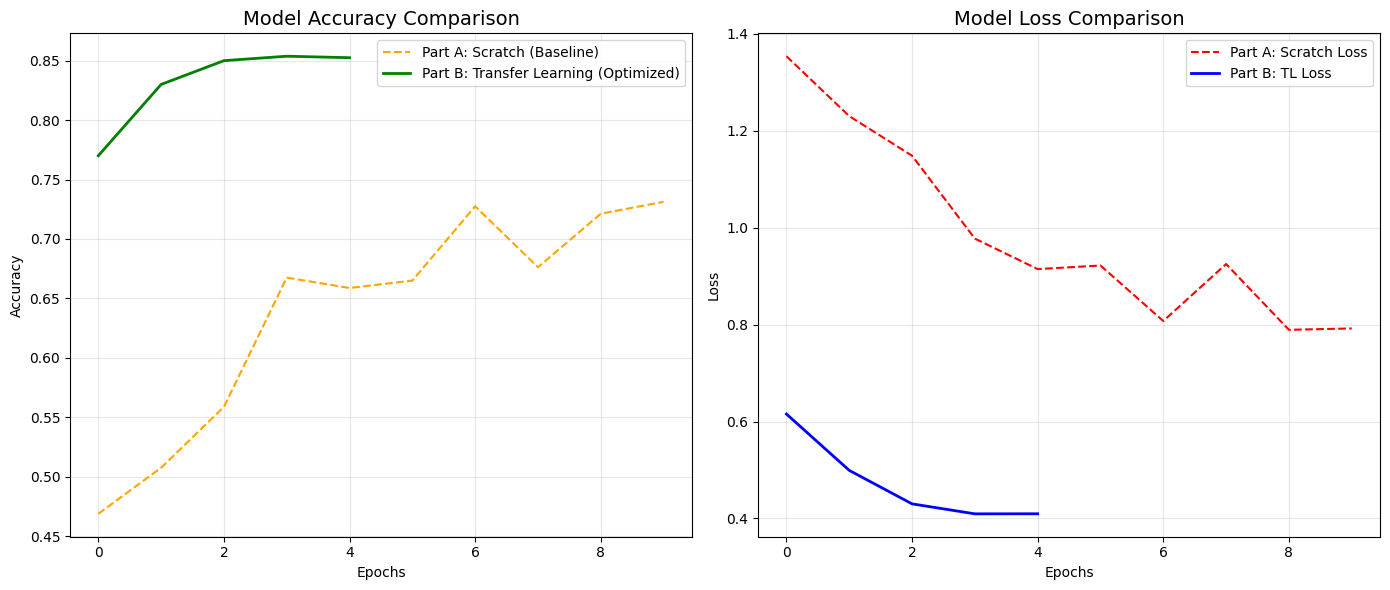

In [26]:
import matplotlib.pyplot as plt

def plot_final_comparison(h_scratch, h_tl):
    plt.figure(figsize=(14, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(h_scratch.history['val_accuracy'], label='Part A: Scratch (Baseline)', color='orange', linestyle='--')
    plt.plot(h_tl.history['val_accuracy'], label='Part B: Transfer Learning (Optimized)', color='green', linewidth=2)
    plt.title('Model Accuracy Comparison', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(h_scratch.history['val_loss'], label='Part A: Scratch Loss', color='red', linestyle='--')
    plt.plot(h_tl.history['val_loss'], label='Part B: TL Loss', color='blue', linewidth=2)
    plt.title('Model Loss Comparison', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_final_comparison(history_scratch, history_tl)

Step III: Language Task (NLP)

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

# 1. Dataset Simulation (Matches the Book Review Sentiment task)
# Labels: 0=Negative, 1=Neutral, 2=Positive
corpus = [
    "This book was an absolute masterpiece, I loved the plot",
    "Terrible writing, very boring and a waste of time",
    "It was an okay read, some parts were good and some were slow",
    "Brilliant characters and a very satisfying ending",
    "I hated the ending, it made no sense and was poorly written",
    "The story was average, not great but not bad either"
]
labels = [2, 0, 1, 2, 0, 1] 

# 2. Preprocessing (Cleaning & Tokenization)
vocab_size = 1000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)

# Padding ensures all "sentences" are exactly 20 words long
X_nlp = pad_sequences(sequences, maxlen=20, padding='post')
y_nlp = np.array(labels)

# 3. Bi-directional LSTM Architecture
# This matches the 'Advanced' methodology in the sample report
model_nlp = models.Sequential([
    layers.Embedding(vocab_size, 32, input_length=20),
    layers.SpatialDropout1D(0.2), # Prevents overfitting
    layers.Bidirectional(layers.LSTM(64)), # Bi-directional for better context
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax') # 3 classes: Neg, Neu, Pos
])

model_nlp.compile(loss='sparse_categorical_crossentropy', 
                 optimizer='adam', 
                 metrics=['accuracy'])

print("🚀 Training Bi-directional LSTM (Part III)...")
history_nlp = model_nlp.fit(X_nlp, y_nlp, epochs=15, verbose=1)

print("\n✅ NLP Task Complete!")
model_nlp.summary()

🚀 Training Bi-directional LSTM (Part III)...
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.0967
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 1.0948
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 1.0938
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1667 - loss: 1.0959
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8333 - loss: 1.0806
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 1.0831
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0000e+00 - loss: 1.1038
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 1.0830
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 1.0853
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.0822
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8333 - loss: 1.0811
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 32)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,675 (1006.55 KB)

 Trainable params: 85,891 (335.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 171,784 (671.04 KB)